In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
import pandas as pd
from numpy.random import choice

In [2]:
import emcee
import pymc

In [3]:
from scipy import integrate
from scipy.stats import norm
from scipy.stats import cauchy


In [4]:
path = '../solutions/transient.npy'

In [5]:
data = np.load(path)
np.shape(data)
times = []
F = []
sF = []
for i in range(100):
    times = np.append(times,data[i][0])
    F = np.append(F,data[i][1])
    sF = np.append(sF,data[i][2])



<ErrorbarContainer object of 3 artists>

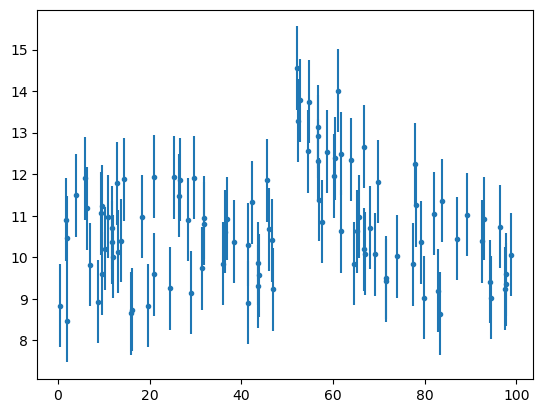

In [6]:
plt.errorbar(times,F,sF,linestyle='',fmt='.')

In [7]:
#data[1] flux, data[2] err on flux

In [8]:
theta0 = np.array([5,10,50,0.1]) #initial guess for A,b,t0,alpha

In [9]:
Amin, Amax = 0, 50
bmin, bmax = 0, 50
t0min, t0max = 0, 100
alphamin, alphamax = np.exp(-5),np.exp(5)

In [10]:
def b_model(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

In [11]:
def log_likelihood(theta, x, y, yerr):
    A,b,t0,alpha = theta
    y_model = b_model(theta,x)

    return -0.5 * np.sum((y - y_model) ** 2 / yerr**2 )
        
def log_prior(theta):
    A,b,t0,alpha=theta 
    if Amin < A < Amax and bmin < b < bmax and t0min < t0 < t0max and alphamin < alpha < alphamax:
        return - np.log(alpha)
    return -np.inf
                   
def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [12]:
ndim = 4  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
nsteps = int(1e4)  # number of MCMC steps to take **for each walker**
pos = theta0 + 1e-1 * np.random.randn(nwalkers, ndim) # initial states for each walker --> dim (20,4)

In [13]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior, args=(times, F, sF)
)

In [14]:
sampler.run_mcmc(pos, nsteps, progress=True)

  0%|                                                                                         | 0/10000 [00:00<?, ?it/s]/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:08<00:00, 1194.31it/s]


State([[ 5.93194652 10.46579647 49.7671381   0.18539089]
 [ 4.61141709 10.29050722 51.53078556  0.14433284]
 [ 6.92154078 10.20647122 48.70354139  0.14823705]
 [ 4.61783432 10.2693035  48.82615137  0.09887181]
 [ 6.85271174 10.35443809 47.74522556  0.13981709]
 [ 6.091941   10.14699899 47.67747426  0.10129596]
 [ 8.09607668 10.37523154 48.61662085  0.1621518 ]
 [ 7.4614457  10.25440054 48.0270686   0.159604  ]
 [ 7.13052515 10.48046086 47.87386518  0.16055262]
 [ 6.30224062 10.28957119 47.55953505  0.11571824]
 [ 3.64505191 10.55679269 49.72123895  0.10671986]
 [ 5.41054633 10.15272234 49.137909    0.10157742]
 [ 7.60733099 10.32644393 46.88267742  0.1133852 ]
 [ 5.84486468 10.44062439 46.93917595  0.11008774]
 [ 8.54341581 10.5248134  46.91254393  0.14119261]
 [ 4.12656515 10.32079381 49.26689707  0.12959065]
 [ 5.06749596 10.3115837  50.44451945  0.11021976]
 [ 3.44851853 10.5357799  52.10268608  0.15947102]
 [ 6.02025763 10.29667187 47.72650661  0.1326891 ]
 [ 5.08637936 10.27477295

In [15]:
sampler.acceptance_fraction # just a bit above 50% could spare slightly larger steps?

array([0.5239, 0.5279, 0.5334, 0.5353, 0.5249, 0.5395, 0.5141, 0.5336,
       0.5303, 0.5227, 0.5361, 0.5268, 0.5222, 0.5296, 0.528 , 0.5294,
       0.5424, 0.531 , 0.533 , 0.5376])

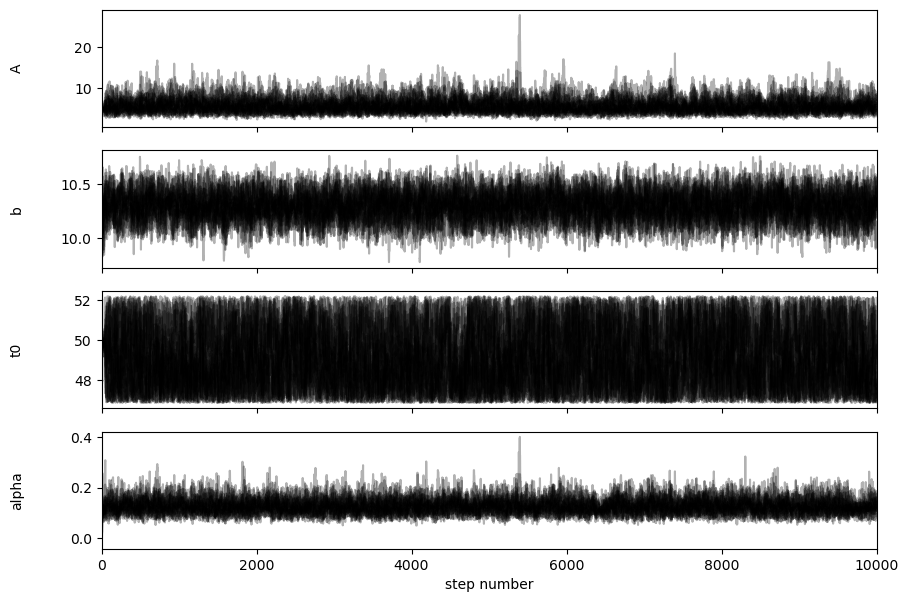

In [16]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain() # dim (nsteps,nwalkers,ndim) = (10000, 20, 4)
labels = ["A","b","t0","alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [17]:
tau = sampler.get_autocorr_time()
print(tau)

[71.27166101 49.95235397 80.69806979 59.73432355]


In [18]:
# def burst(theta,t):
#     A,b,t0,alpha=theta 
#     return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

In [19]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True) #chain thinned based on the largest correletion length and burn-in set to 3* largest correletion length
print(flat_samples.shape)

(2440, 4)


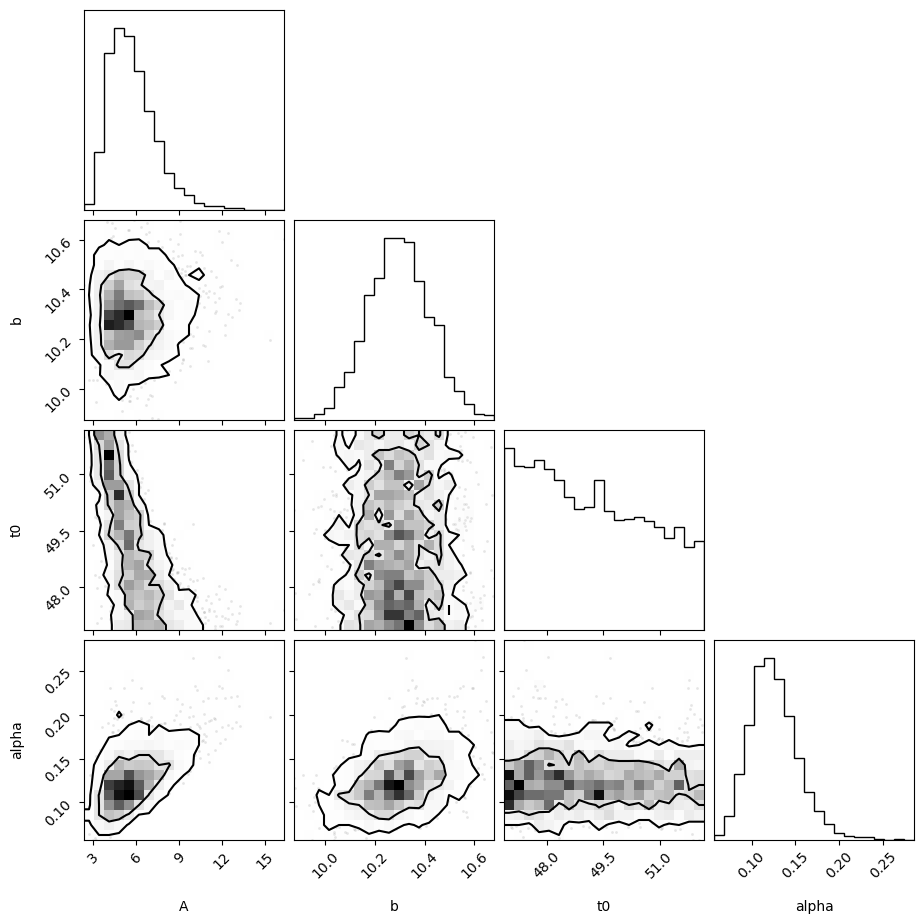

In [20]:
import corner
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95]) #contours at 68 and 95%

In [21]:
# 100 samples randomly from your burned, thinned chain and plot the 100 corresponding burst time-series on a figure along with the original data
chosen_samples= flat_samples[np.random.choice(len(flat_samples),size=100)]

Text(0, 0.5, 'flux')

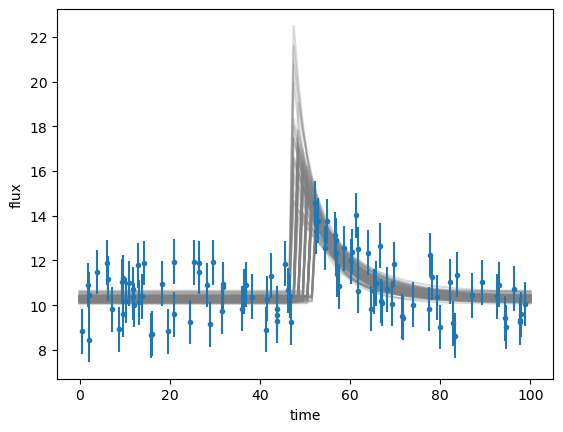

In [23]:
tgrid=np.linspace(0,100,100)

for chosen_theta in chosen_samples:
    ygrid =  b_model(chosen_theta,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.3,c='gray')
    
plt.errorbar(times,F,yerr=sF,fmt='.')
plt.xlabel("time")
plt.ylabel("flux")

In [24]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [5,50,95]) # 50th percentile = median, 95-5 = 90% credibility 
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>